In [ ]:
# Vereisten: pip install fredapi pandas numpy

from fredapi import Fred
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

load_dotenv()

In [ ]:
API_KEY = os.getenv('API_KEY_FRED')
FRED = Fred(api_key=API_KEY)

In [2]:
start_date = '2016-01-01'
end_date = datetime.date.today().strftime('%Y-%m-%d')

In [3]:
daily_series = {
    "USD": "DTWEXBGS",
    "OIL": "DCOILWTICO",
}

In [4]:
daily_series.keys()

dict_keys(['USD', 'OIL'])

In [5]:
monthly_series = {
    "GS10": "GS10",
    "GS2": "GS2",
    "GDP": "GDP",
    "CPI": "CPIAUCSL",
    "Unemployment": "UNRATE",
    "PPI": "PPIACO",
    "Personal_Income": "PI",
    "FedFundsRate": "FEDFUNDS",
    "Labor_Participation": "CIVPART",
    "Employment": "PAYEMS",
    "Consumer_Confidence": "UMCSENT",
}

In [ ]:
daily_dfs = []

for name, sid in daily_series.items():
    s = FRED.get_series(sid, observation_start=start_date, observation_end=end_date)
    df = s.to_frame(name)
    daily_dfs.append(df)

df_daily = pd.concat(daily_dfs, axis=1)
df_daily.index.name = "Date"
df_daily = df_daily.sort_index()

In [ ]:
monthly_dfs = []

for name, sid in monthly_series.items():
    s = FRED.get_series(sid, observation_start=start_date, observation_end=end_date)
    df = s.to_frame(name)

    # Economisch zinnige transformaties
    df[f"{name}_MoM"] = df[name].pct_change()
    df[f"{name}_YoY"] = df[name].pct_change(12)

    monthly_dfs.append(df)

df_monthly = pd.concat(monthly_dfs, axis=1)
df_monthly.index.name = "Date"

In [8]:
# Herindexeer maanddata naar dagelijkse index
df_monthly_daily = df_monthly.reindex(df_daily.index, method="ffill")

In [9]:
df_all = df_daily.join(df_monthly_daily)

In [10]:
df_all.reset_index(inplace=True)
df_all.to_csv("fred_combined_daily_macro.csv", index=False)

print("✅ Dataset opgeslagen als fred_combined_daily_macro.csv")
print(df_all.info())

✅ Dataset opgeslagen als fred_combined_daily_macro.csv
<class 'pandas.DataFrame'>
RangeIndex: 2677 entries, 0 to 2676
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     2677 non-null   datetime64[us]
 1   USD                      2556 non-null   float64       
 2   OIL                      2565 non-null   float64       
 3   GS10                     2677 non-null   float64       
 4   GS10_MoM                 2656 non-null   float64       
 5   GS10_YoY                 2416 non-null   float64       
 6   GS2                      2677 non-null   float64       
 7   GS2_MoM                  2656 non-null   float64       
 8   GS2_YoY                  2416 non-null   float64       
 9   GDP                      876 non-null    float64       
 10  GDP_MoM                  855 non-null    float64       
 11  GDP_YoY                  618 non-null    float64   

In [11]:
df.tail()
df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 122 entries, 2016-01-01 to 2026-02-01
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Consumer_Confidence      122 non-null    float64
 1   Consumer_Confidence_MoM  121 non-null    float64
 2   Consumer_Confidence_YoY  110 non-null    float64
dtypes: float64(3)
memory usage: 7.9 KB


In [12]:
daily_series.values()

dict_values(['DTWEXBGS', 'DCOILWTICO'])

In [13]:
for col in df_all.columns:
    if col == "Date":
        print(min(df_all[col]))
        print(max(df_all[col]))
    print(col, df_all[col].last_valid_index())
    


2016-01-01 00:00:00
2026-04-06 00:00:00
Date 2676
USD 2675
OIL 2676
GS10 2676
GS10_MoM 2676
GS10_YoY 2676
GS2 2676
GS2_MoM 2676
GS2_YoY 2676
GDP 2565
GDP_MoM 2565
GDP_YoY 2565
CPI 2676
CPI_MoM 2676
CPI_YoY 2676
Unemployment 2676
Unemployment_MoM 2676
Unemployment_YoY 2676
PPI 2650
PPI_MoM 2650
PPI_YoY 2650
Personal_Income 2650
Personal_Income_MoM 2650
Personal_Income_YoY 2650
FedFundsRate 2676
FedFundsRate_MoM 2676
FedFundsRate_YoY 2676
Labor_Participation 2676
Labor_Participation_MoM 2676
Labor_Participation_YoY 2676
Employment 2676
Employment_MoM 2676
Employment_YoY 2676
Consumer_Confidence 2650
Consumer_Confidence_MoM 2650
Consumer_Confidence_YoY 2650


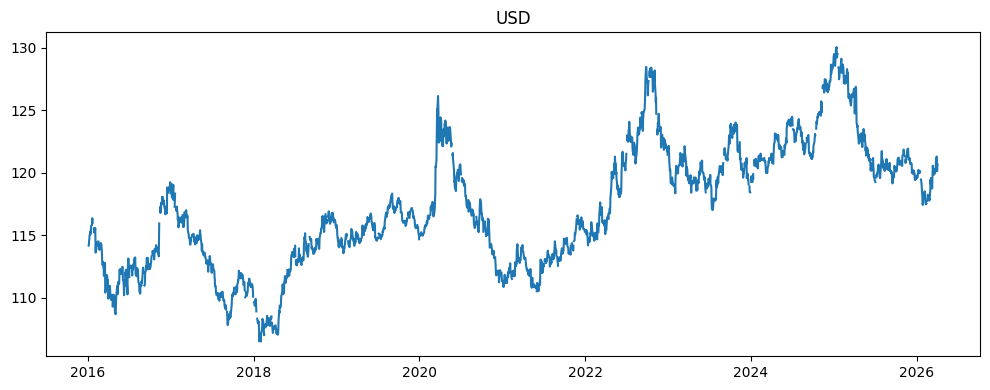

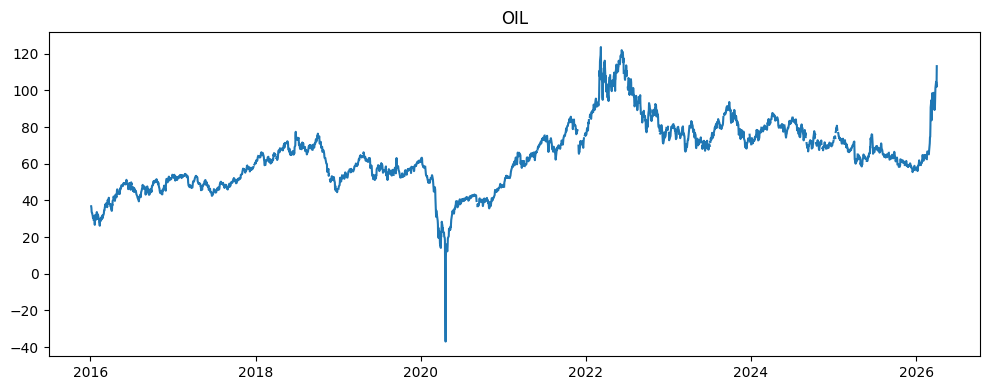

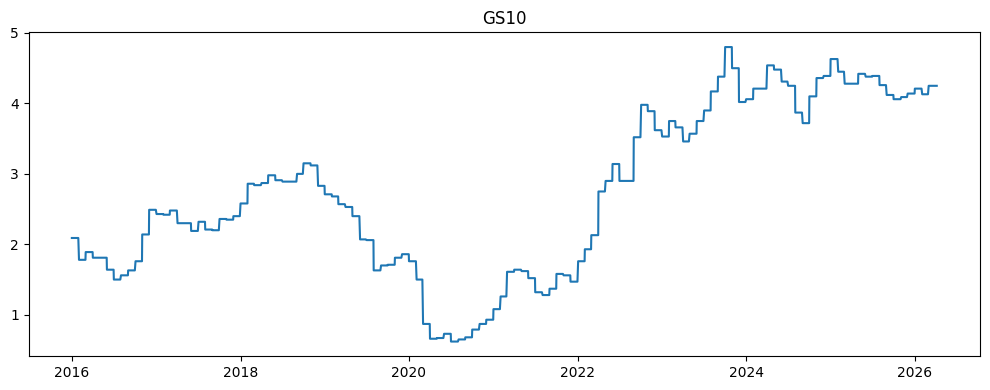

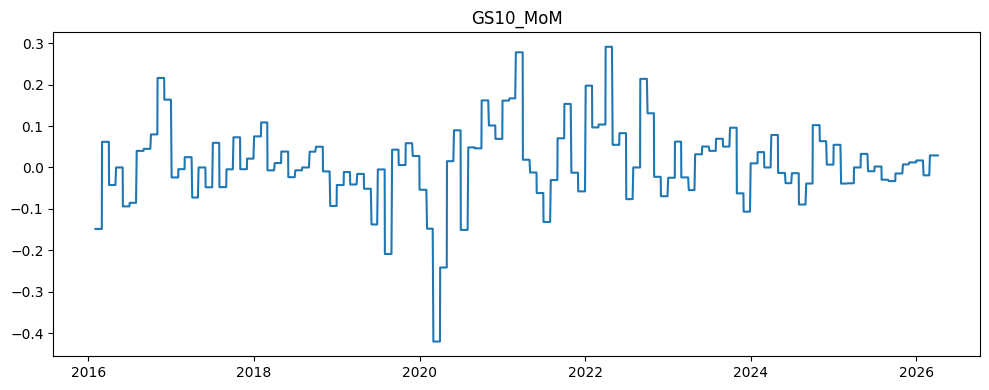

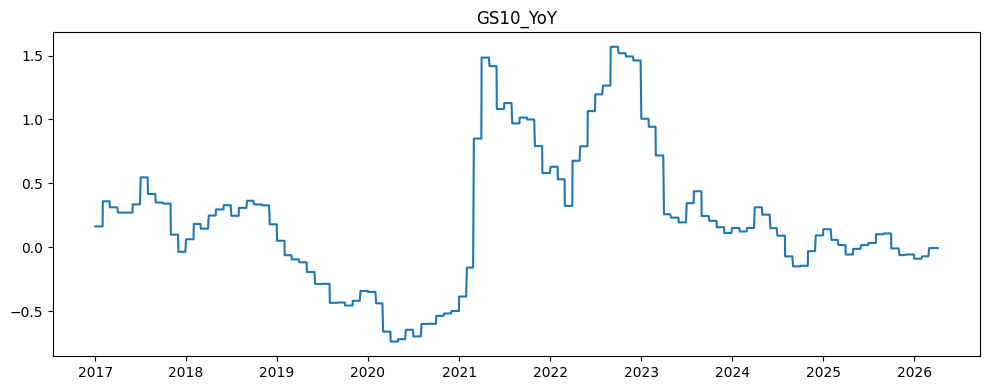

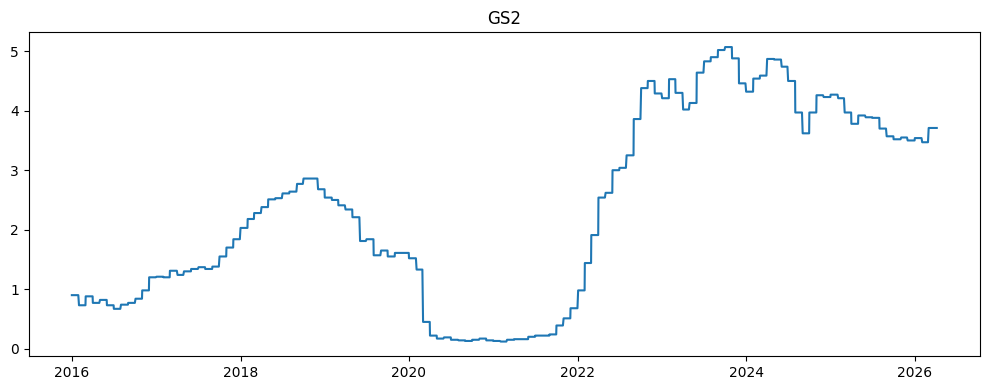

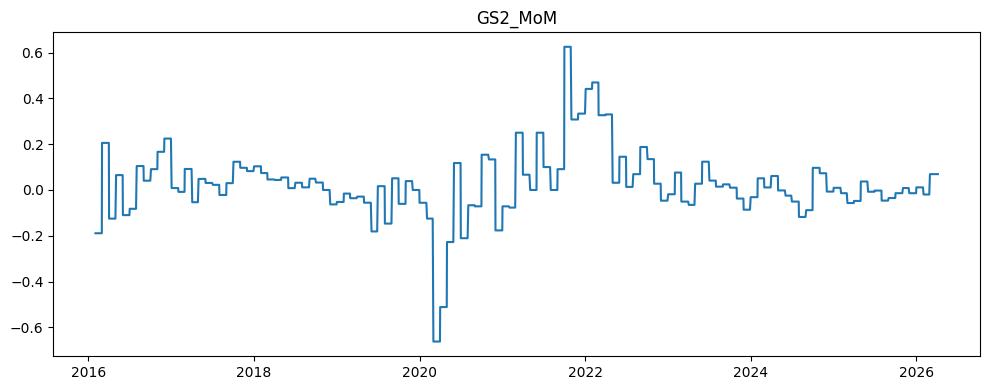

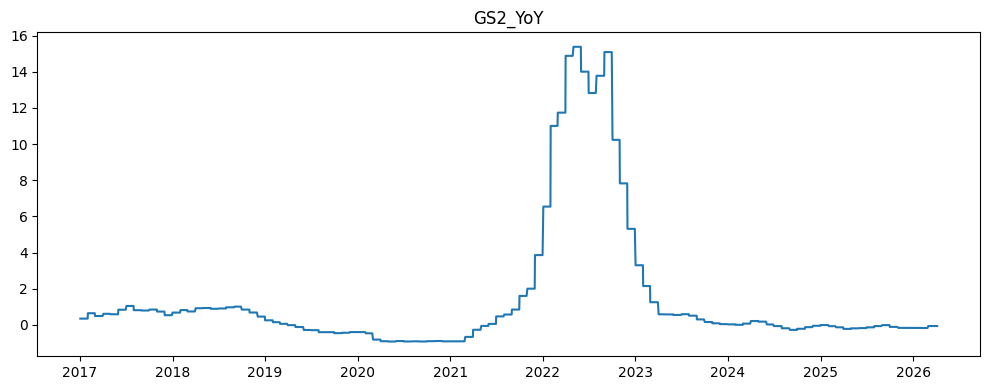

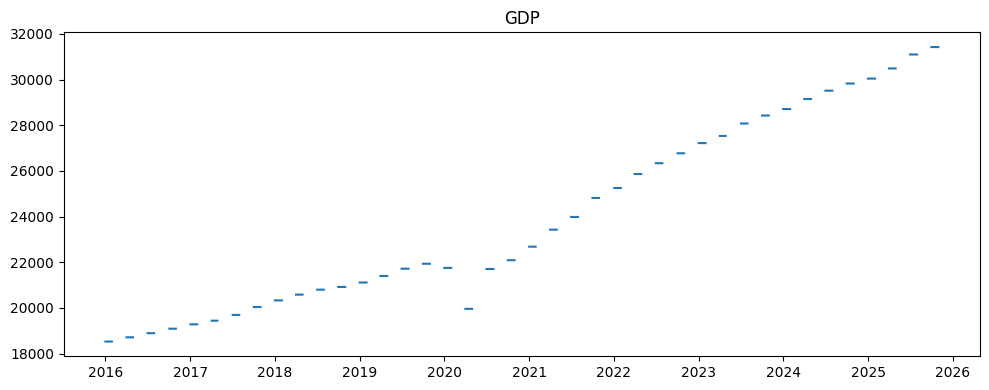

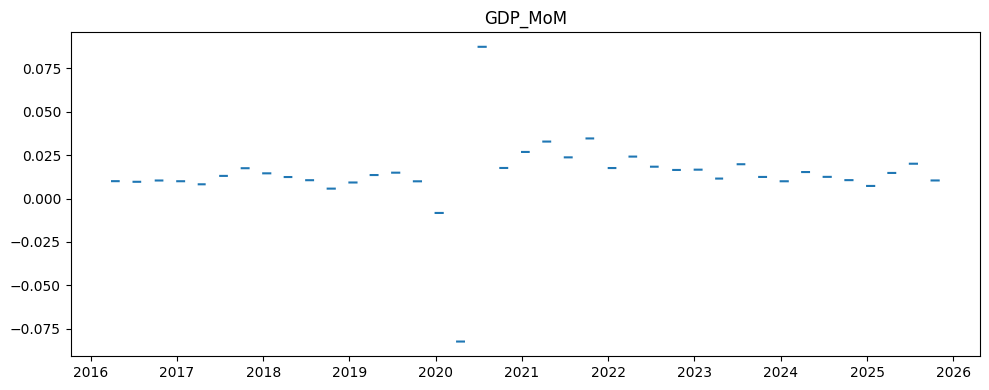

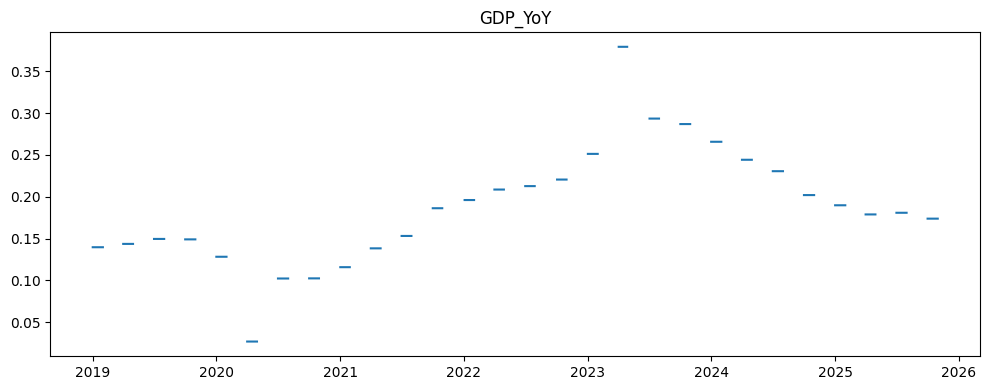

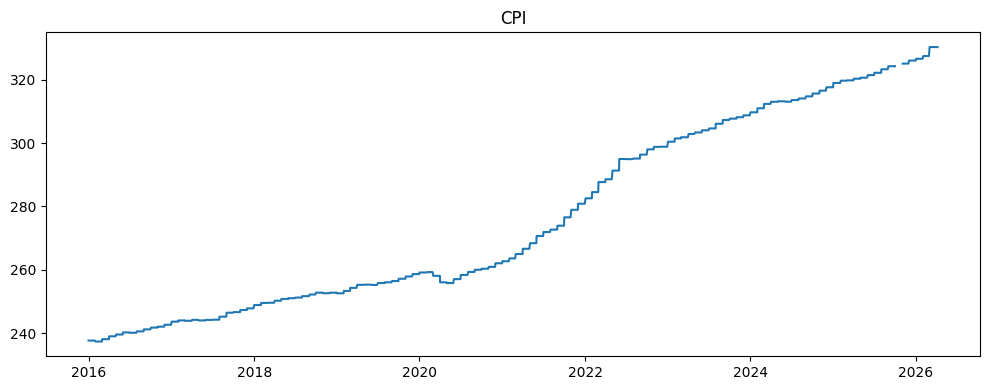

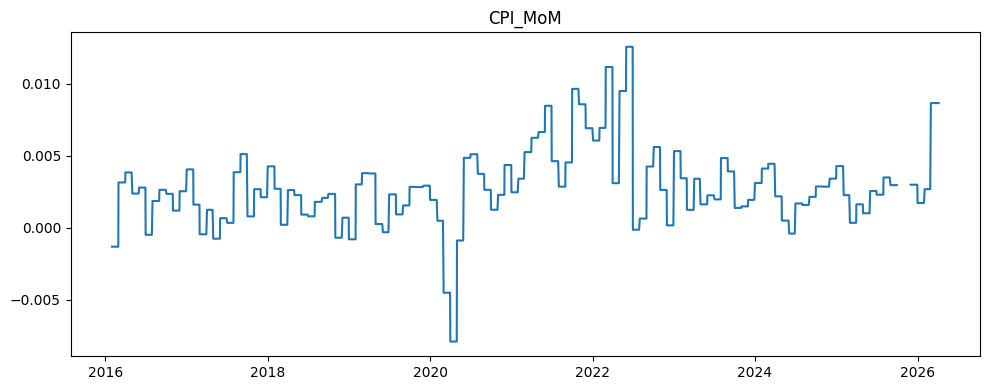

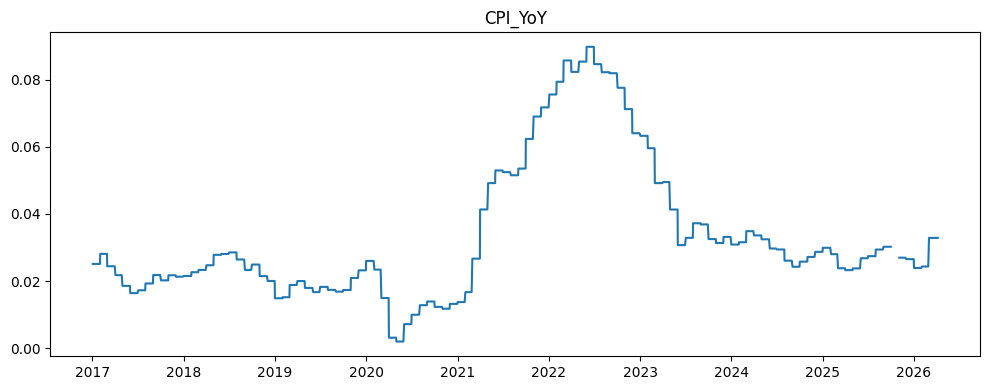

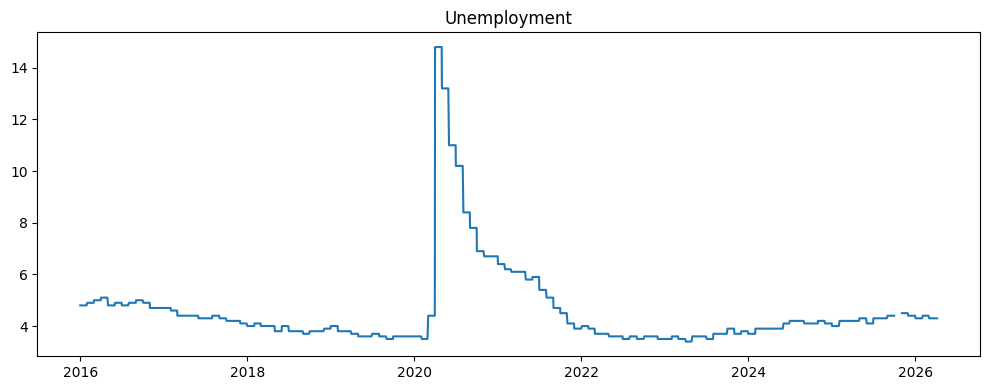

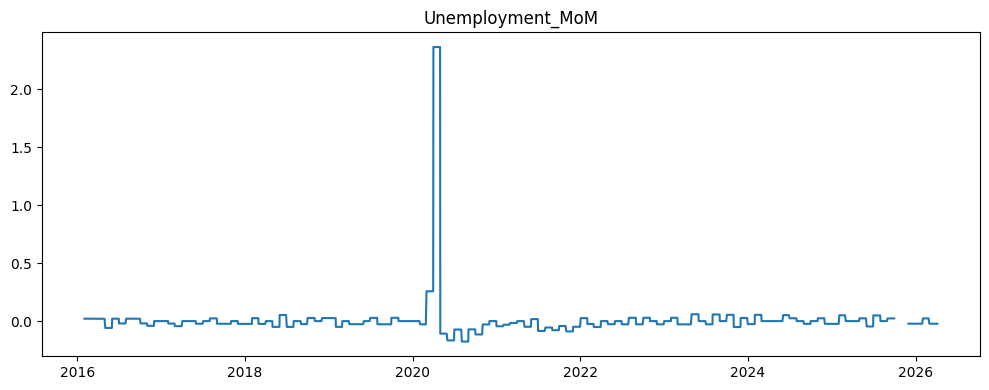

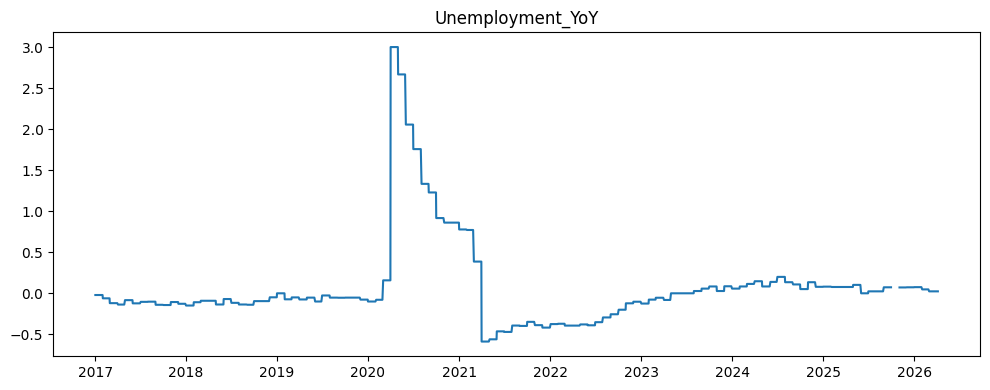

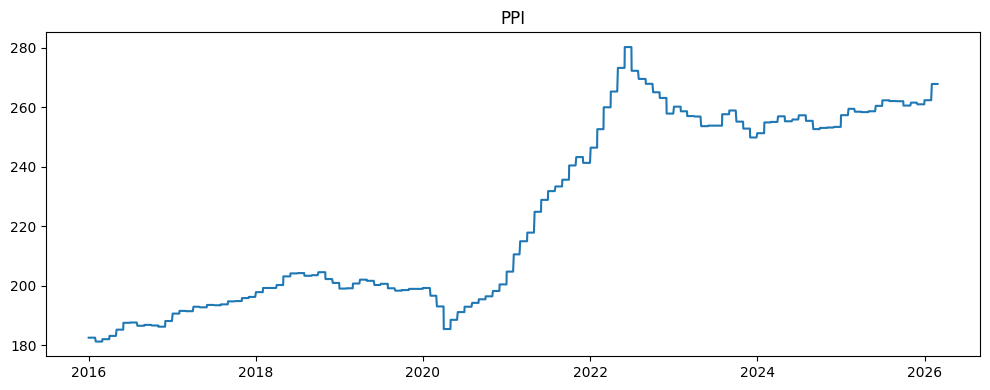

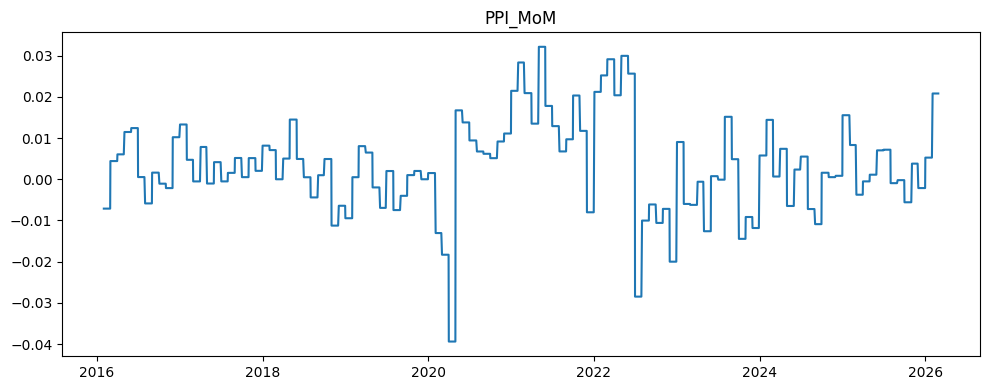

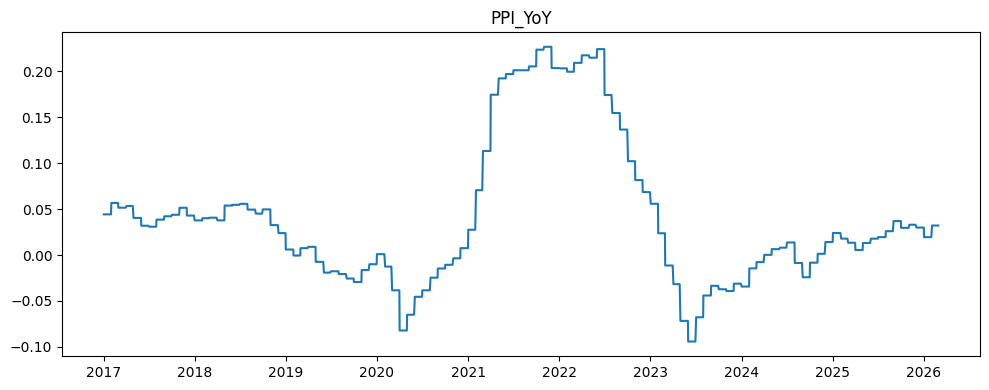

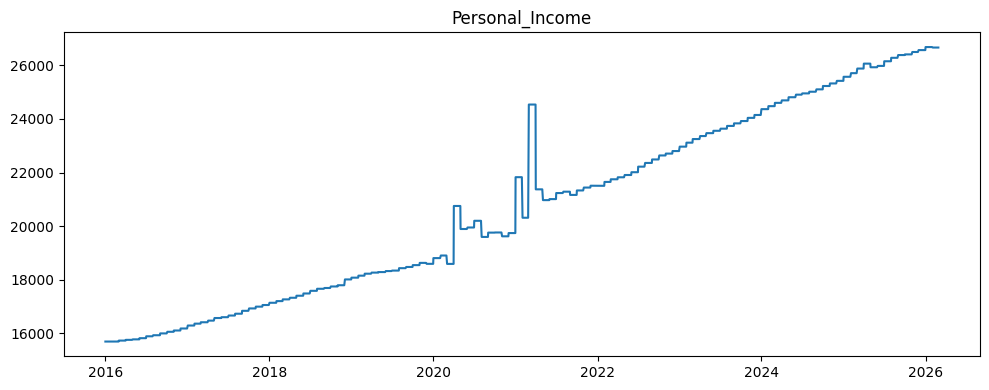

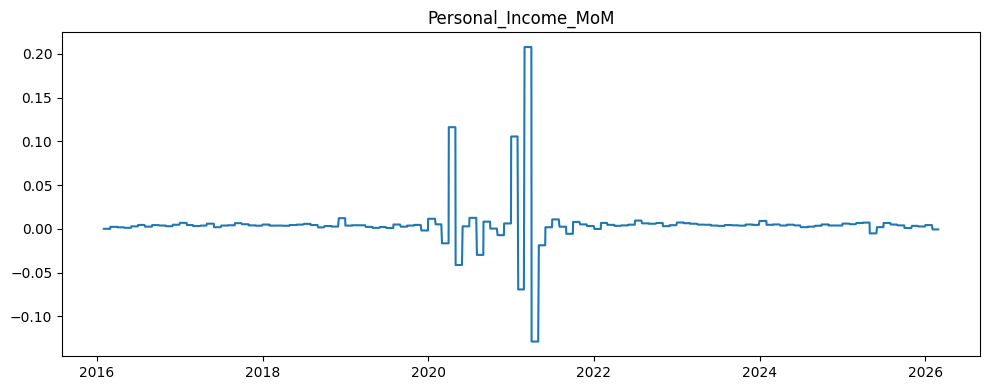

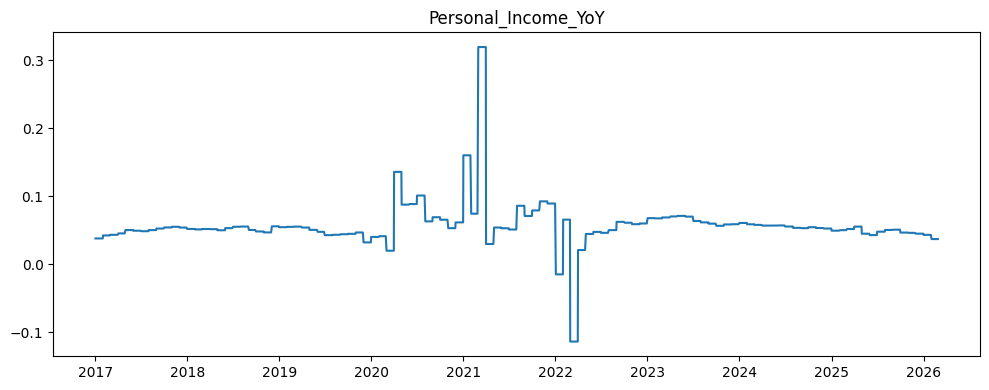

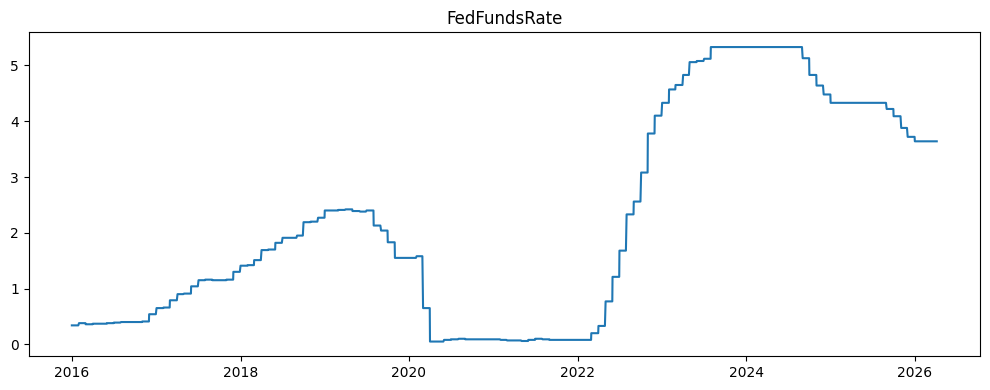

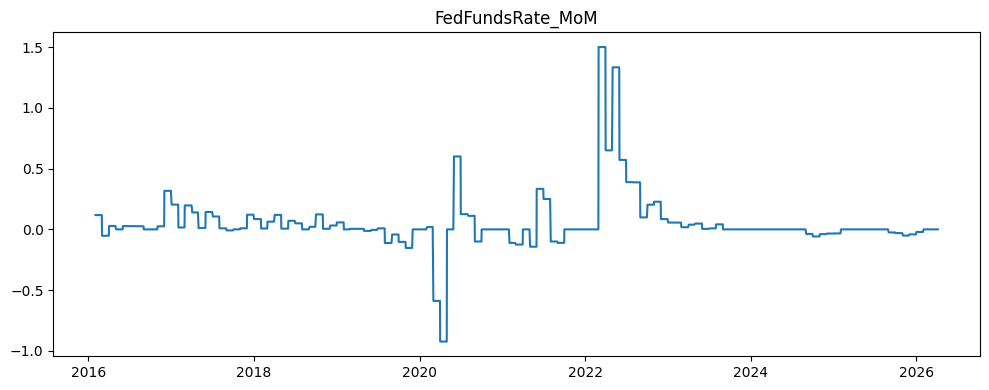

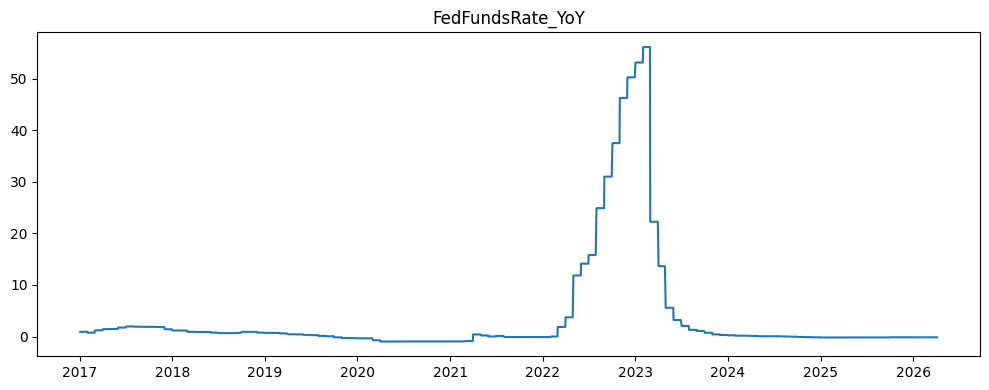

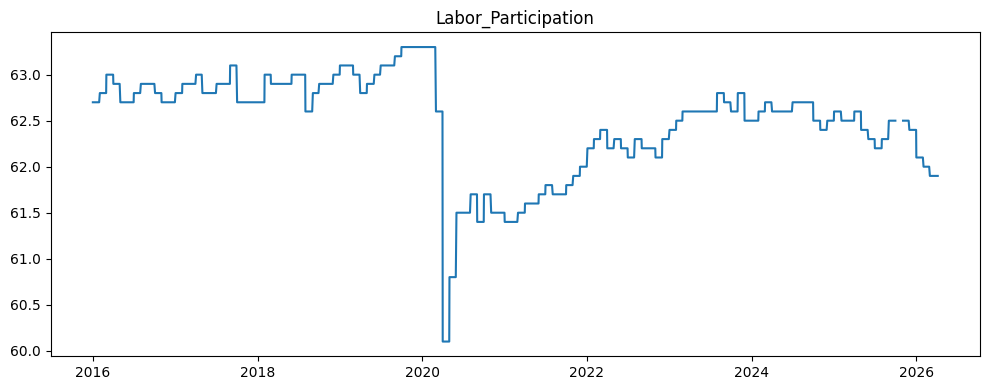

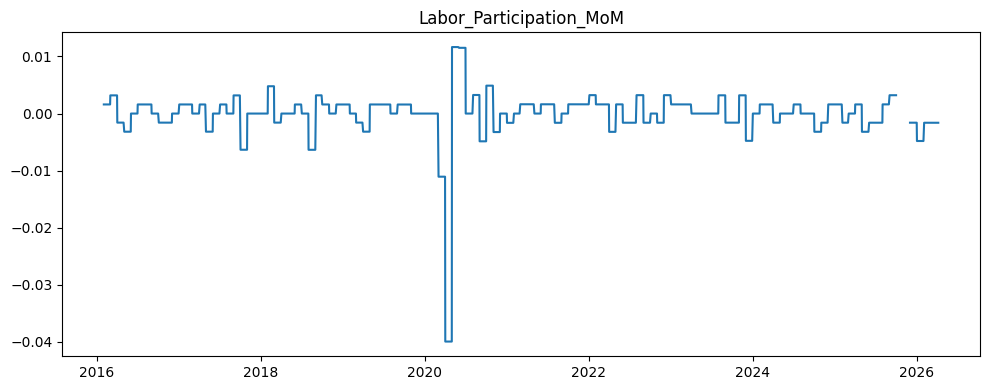

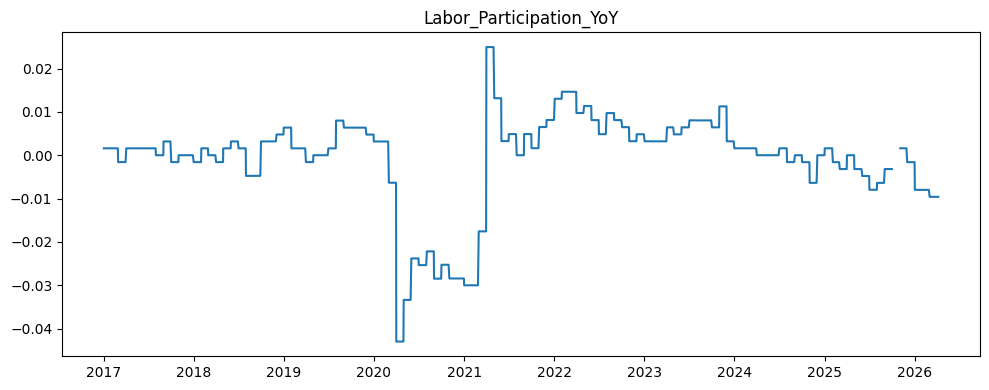

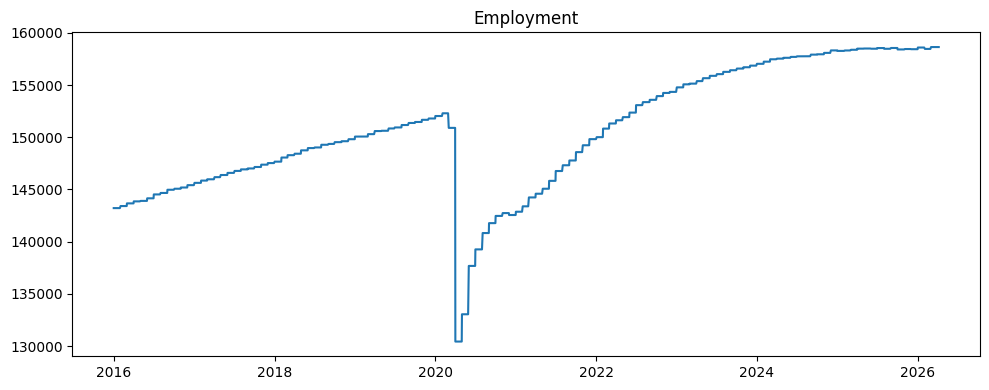

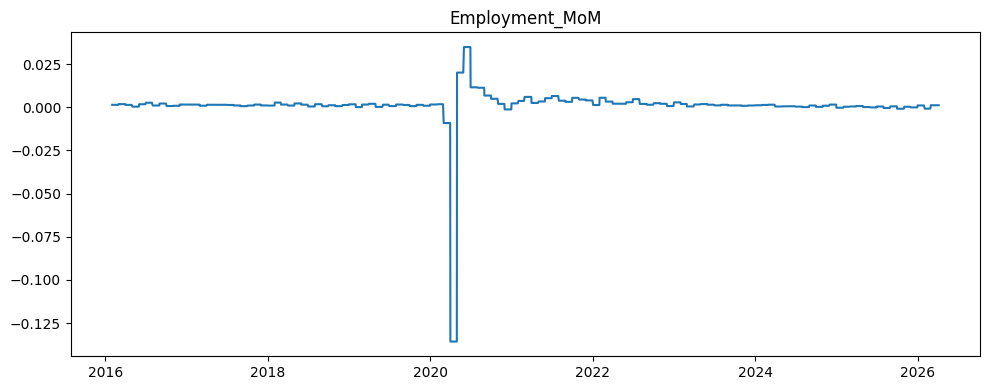

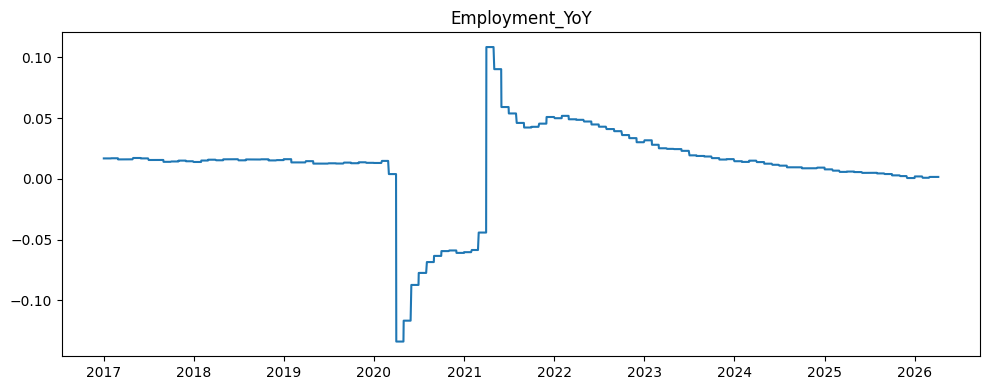

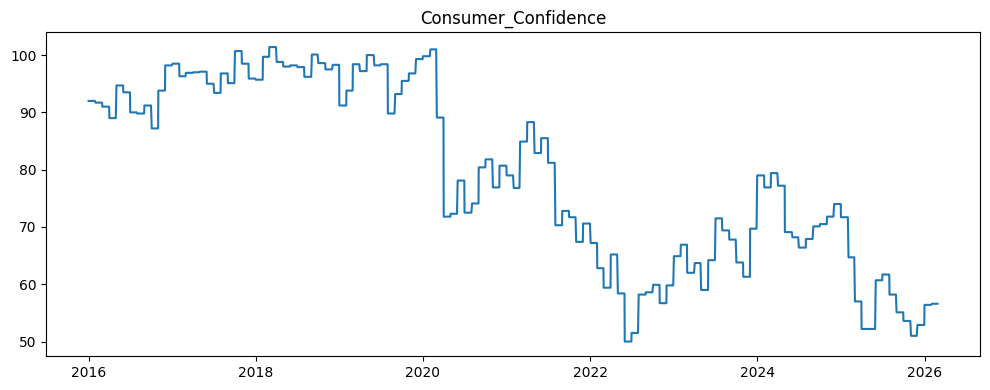

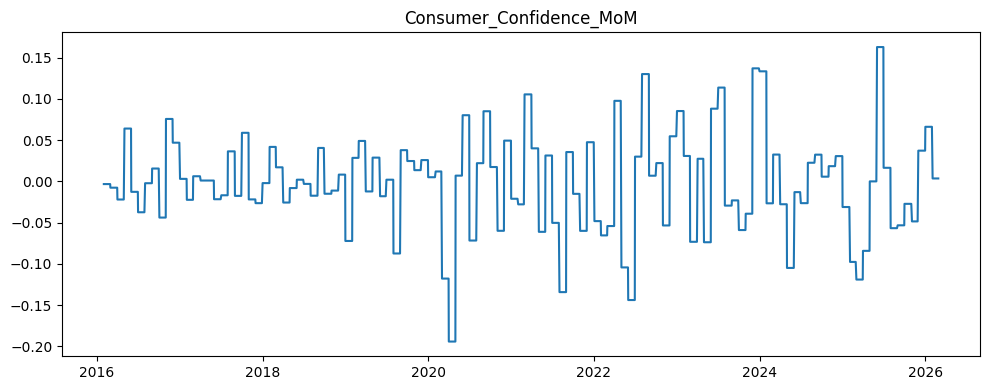

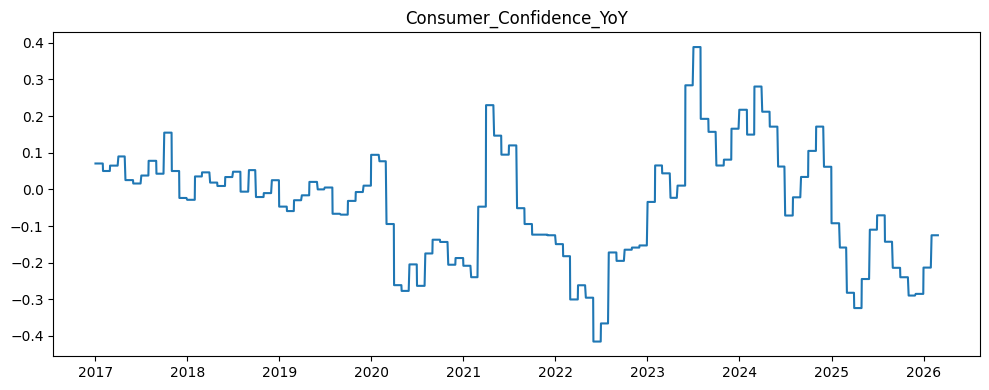

In [14]:
for col in df_all.columns:
    if col != "Date":
        plt.figure(figsize=(10, 4))
        plt.plot(df_all["Date"], df_all[col])
        plt.title(col)
        plt.tight_layout()
        plt.show()